# 로보플로우 데이터 가져오기 위한 설정

## 숨김 파일을 볼 수 있도록 하는 설정
jupyter lab --ContentsManager.allow_hidden=True


In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

# 현재 프로젝트 폴더의 .env 읽기
load_dotenv(dotenv_path=Path(".env"))

api_key = os.getenv("ROBOFLOW_API_KEY")

if api_key is None:
    raise ValueError("ROBOFLOW_API_KEY를 찾지 못했습니다. .env 파일 위치를 확인하세요.")

print("API Key 로드 완료")
print(api_key[:5] + "..." + api_key[-4:])

API Key 로드 완료
u1LNm...YM9f


* 코드에 적용하기
```
import os
from pathlib import Path
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv(dotenv_path=Path("/Users/science/workspace/RAIMScope/.env"))

rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
```

# YOLO 사전학습 모델 사용법 익히기

* 데이터 파일 출처: https://github.com/neowizard2018/neowizard

In [2]:
import os
import zipfile

In [78]:
with zipfile.ZipFile('./RawData/test.zip') as test_file:
    test_file.extractall('./test_image_dir')

In [3]:
from PIL import Image as PILimage
from IPython.display import Image

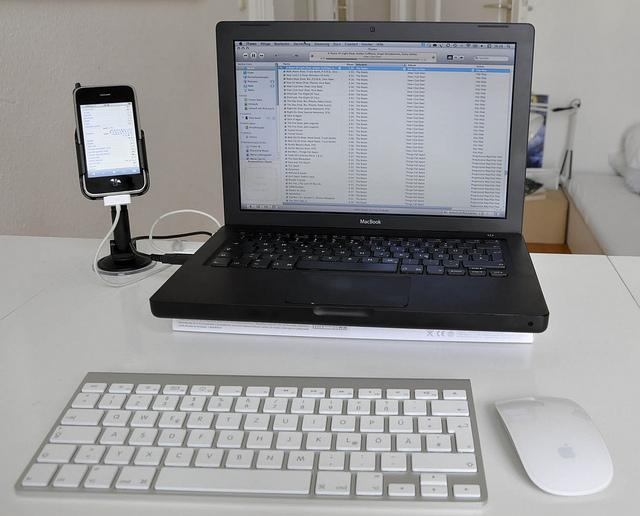

In [82]:
test_image = Image('test_image_dir/test1.jpg')
display(test_image)

In [4]:
from pathlib import Path
import random

In [84]:
# set the path for images
base_dir = Path('test_image_dir')

# image extension setup
image_exts={".jpg",".jpeg", ".png", ".bmp", ".webp"}

In [85]:
# make list for images
image_file_list =[
    p for p in base_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
]

In [86]:
print(image_file_list)

[PosixPath('test_image_dir/test4.jpg'), PosixPath('test_image_dir/test1.jpg'), PosixPath('test_image_dir/test3.jpg'), PosixPath('test_image_dir/test2.jpg')]


In [87]:
selected = random.sample(image_file_list, 3)
print(" ".join(str(p) for p in selected))

test_image_dir/test4.jpg test_image_dir/test2.jpg test_image_dir/test1.jpg


In [5]:
# show the images
import matplotlib.pyplot as plt

In [89]:
plt.figure(figsize=(12,4))

for i, img_path in enumerate(selected):
    img = PILimage.open(img_path)

    plt.subplot(1, len(selected), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)

plt.tight_layout()
plt.show()


<Figure size 1200x400 with 3 Axes>

# Yolo 11 사전 훈련 모델 이용하기

In [6]:
import ultralytics
from ultralytics import YOLO

In [91]:
model = YOLO('yolo11n.pt')

In [92]:
from pprint import pprint
pprint(model.names, width=60)

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [93]:
print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [94]:
results = model(source='test_image_dir/*', save=True)


image 1/4 /Users/science/workspace/RAIMScope/test_image_dir/test1.jpg: 544x640 1 laptop, 1 mouse, 1 keyboard, 1 cell phone, 28.9ms
image 2/4 /Users/science/workspace/RAIMScope/test_image_dir/test2.jpg: 448x640 4 zebras, 1 giraffe, 21.6ms
image 3/4 /Users/science/workspace/RAIMScope/test_image_dir/test3.jpg: 640x640 2 cups, 1 bowl, 2 sandwichs, 1 dining table, 26.6ms
image 4/4 /Users/science/workspace/RAIMScope/test_image_dir/test4.jpg: 480x640 2 persons, 1 truck, 1 horse, 19.9ms
Speed: 0.9ms preprocess, 24.2ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /Users/science/workspace/RAIMScope/runs/detect/predict-7


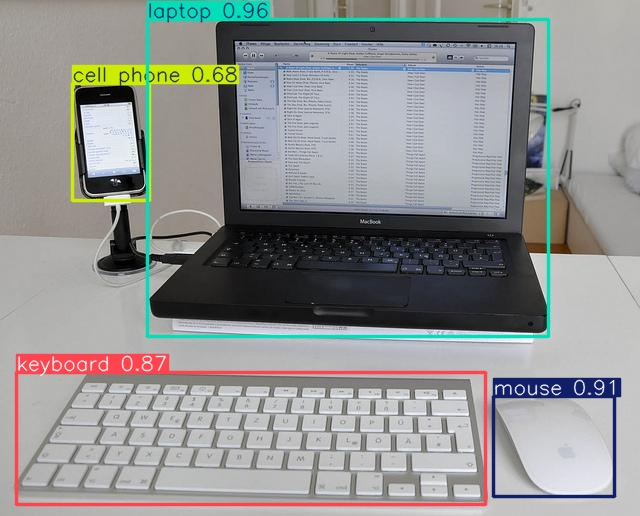

runs/detect/predict/test1.jpg


In [95]:
import random, glob
from IPython.display import Image, display

img_path = random.choice(glob.glob("runs/detect/predict/*.jpg"))

display(Image(filename=img_path))
print(img_path)

In [96]:
# checkout the result
import numpy as np

for result in results:
    uniq, cnt = np.unique(result.boxes.cls.cpu().numpy(), return_counts=True)
    uniq_cnt_dict = dict(zip(uniq, cnt))

    print('\n{class num: counts} = ',uniq_cnt_dict, '\n')

    for c in result.boxes.cls:
        print('class num =', int(c), ', class_name= ', model.names[int(c)])


{class num: counts} =  {np.float32(63.0): np.int64(1), np.float32(64.0): np.int64(1), np.float32(66.0): np.int64(1), np.float32(67.0): np.int64(1)} 

class num = 63 , class_name=  laptop
class num = 64 , class_name=  mouse
class num = 66 , class_name=  keyboard
class num = 67 , class_name=  cell phone

{class num: counts} =  {np.float32(22.0): np.int64(4), np.float32(23.0): np.int64(1)} 

class num = 23 , class_name=  giraffe
class num = 22 , class_name=  zebra
class num = 22 , class_name=  zebra
class num = 22 , class_name=  zebra
class num = 22 , class_name=  zebra

{class num: counts} =  {np.float32(41.0): np.int64(2), np.float32(45.0): np.int64(1), np.float32(48.0): np.int64(2), np.float32(60.0): np.int64(1)} 

class num = 48 , class_name=  sandwich
class num = 60 , class_name=  dining table
class num = 48 , class_name=  sandwich
class num = 41 , class_name=  cup
class num = 41 , class_name=  cup
class num = 45 , class_name=  bowl

{class num: counts} =  {np.float32(0.0): np.int64

# 사용자 파일을 이용한 파인튜닝

In [97]:
#import sys
#!uv pip install --python {sys.executable} python-dotenv roboflow ultralytics

In [98]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()

rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))

 * 가위 바위 보 데이터를 얻을 수 있는 곳으로 링크를 클릭하면 다운로드 받을 수 있음
 * 다운로드 후 파일을 업로드해서 진행하면 됨  
 [가위바위보 데이터 바로가기](https://universe.roboflow.com/ds/iF6fCPQE5B?key=mHQWwhYNqO)

* YOLO 데이터를 다운받은 후에는 yaml 파일을 수정해서 프로젝트에 맞게 설정해주어야 함.

In [99]:
import yaml

In [100]:
!cat rock-paper-scissors/data.yaml

names:
- Paper
- Rock
- Scissors
nc: 3
test: test/images
train: train/images
val: valid/images


In [101]:
data = {'train' : 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'names': ['Paper', 'Rock', 'Scissors'],
        'nc': 3}

In [102]:
with open('rock-paper-scissors/data.yaml' , 'w') as f:
    yaml.dump(data,f)

In [103]:
with open('rock-paper-scissors/data.yaml', 'r') as f:
    display(yaml.safe_load(f))

{'names': ['Paper', 'Rock', 'Scissors'],
 'nc': 3,
 'test': 'test/images',
 'train': 'train/images',
 'val': 'valid/images'}

In [104]:
!pwd

/Users/science/workspace/RAIMScope


In [105]:
model.train(data='rock-paper-scissors/data.yaml', 
            epochs=10, 
            batch=8,
            patience=5, 
            imgsz=415,
            device='mps')

Ultralytics 8.4.60 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M5 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rock-paper-scissors/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=415, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0,

KeyboardInterrupt: 

In [84]:
model = YOLO("/Users/science/workspace/RAIMScope/runs/detect/train-3/weights/best.pt")

In [85]:
results = model('rock-paper-scissors/test/images', save=True)


image 1/304 /Users/science/workspace/RAIMScope/rock-paper-scissors/test/images/10e0gvm_jpg.rf.3b68a834fab647f30a57fc3ea92d4cd2.jpg: 416x416 (no detections), 14.8ms
image 2/304 /Users/science/workspace/RAIMScope/rock-paper-scissors/test/images/15208484cellblock_jpg.rf.95cbda1e169a66105fbf2aa22959a73b.jpg: 416x416 (no detections), 12.5ms
image 3/304 /Users/science/workspace/RAIMScope/rock-paper-scissors/test/images/19171_298_298_1_0_jpg.rf.0024dfb25d7b5a13a78e94fca47ef004.jpg: 416x416 (no detections), 12.2ms
image 4/304 /Users/science/workspace/RAIMScope/rock-paper-scissors/test/images/20061004021831_jpg.rf.8667d8aa5599deb901289c024eed4313.jpg: 416x416 (no detections), 12.3ms
image 5/304 /Users/science/workspace/RAIMScope/rock-paper-scissors/test/images/20220216_221550_jpg.rf.02a071a383151953fcf8671fc7fca3af.jpg: 416x416 1 Scissors, 12.3ms
image 6/304 /Users/science/workspace/RAIMScope/rock-paper-scissors/test/images/20220216_221819_jpg.rf.295ebb583293f91f74e1700f0ab0639a.jpg: 416x416 1

# 세그멘테이션 도전하기

In [106]:
model_seg=YOLO('yolo11n-seg.pt')

In [107]:
results = model_seg(source='test_image_dir', save=True)


image 1/4 /Users/science/workspace/RAIMScope/test_image_dir/test1.jpg: 544x640 1 laptop, 1 mouse, 1 keyboard, 1 cell phone, 38.5ms
image 2/4 /Users/science/workspace/RAIMScope/test_image_dir/test2.jpg: 448x640 1 zebra, 1 giraffe, 27.1ms
image 3/4 /Users/science/workspace/RAIMScope/test_image_dir/test3.jpg: 640x640 2 cups, 1 bowl, 2 sandwichs, 1 dining table, 36.4ms
image 4/4 /Users/science/workspace/RAIMScope/test_image_dir/test4.jpg: 480x640 2 persons, 1 bus, 1 truck, 1 horse, 26.6ms
Speed: 0.7ms preprocess, 32.1ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /Users/science/workspace/RAIMScope/runs/segment/predict-3


# 양파 체세포를 이용한 객체 검출 도전하기

In [109]:
#!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key)
project = rf.workspace("csc173-project").project("onion-cell-merged-v5")
version = project.version(2)
dataset = version.download("yolov11")            

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Onion-Cell-Merged-v5-2 in yolov11:: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1300/1300 [00:00<00:00, 10047.07it/s]


In [7]:
!cat Onion-Cell-Merged-v5-2/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['d', 'nd']

roboflow:
  workspace: csc173-project
  project: onion-cell-merged-v5
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/csc173-project/onion-cell-merged-v5/dataset/2

In [8]:
import yaml
yaml_onion = {'train' : 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
         'nc': 2,
         'names': ['d', 'nd']
             }

In [9]:
with open('Mitosis-15/data.yaml', 'w') as f:
    yaml.dump(yaml_onion, f)

FileNotFoundError: [Errno 2] No such file or directory: 'Mitosis-15/data.yaml'

In [114]:
with open('Onion-Cell-Merged-v5-2/data.yaml', 'r') as f:
    display(yaml.safe_load(f))

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 2,
 'names': ['d', 'nd'],
 'roboflow': {'workspace': 'csc173-project',
  'project': 'onion-cell-merged-v5',
  'version': 2,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/csc173-project/onion-cell-merged-v5/dataset/2'}}

In [115]:
model=YOLO('yolo11n.pt')

In [116]:
from pathlib import Path

dataset_dir = Path("/Users/science/workspace/RAIMScope/Onion-Cell-Merged-v5-2")

print("train images:", len(list((dataset_dir / "train/images").glob("*"))))
print("train labels:", len(list((dataset_dir / "train/labels").glob("*.txt"))))
print("valid images:", len(list((dataset_dir / "valid/images").glob("*"))))
print("valid labels:", len(list((dataset_dir / "valid/labels").glob("*.txt"))))

label_files = list((dataset_dir / "train/labels").glob("*.txt"))
print(label_files[0])
print(label_files[0].read_text())

train images: 452
train labels: 452
valid images: 129
valid labels: 129
/Users/science/workspace/RAIMScope/Onion-Cell-Merged-v5-2/train/labels/A_224_png.rf.5aee4e7c99ab4ffccf7f7d1e26081118.txt
0 0.4920568663036903 0.5342325780247968 0.09663641863278888 0.05933732364258228
1 0.25795523290986083 0.5336254809747756 0.06159104658197214 0.05997862334330909
1 0.2572776769509982 0.3008507909362976 0.04228070175438595 0.038495083368961076
1 0.2556624319419238 0.377105600684053 0.047120387174833626 0.03424112868747325
1 0.4663762855414398 0.38907652843095336 0.03700544464609805 0.029683625480974803
1 0.18942528735632183 0.38722530996152205 0.04572292800967939 0.02997007268063271
1 0.06713248638838476 0.4792304403591279 0.061270417422867526 0.037550235143223566
0 0.390961887477314 0.5706412997007269 0.06363581367211135 0.04509191962377076
1 0.4804900181488203 0.6032107738349722 0.05716878402903811 0.049516887558785874
1 0.5913914095583788 0.647537409149209 0.06117967332123405 0.04411286874732784

In [60]:
#import sys
#!uv pip install --python {sys.executable} -U ipywidgets jupyterlab_widgets

In [118]:
from pathlib import Path

dataset_dir = Path("/Users/science/workspace/RAIMScope/Onion-Cell-Merged-v5-2")

for split in ["train", "valid", "test"]:
    image_dir = dataset_dir / split / "images"
    label_dir = dataset_dir / split / "labels"

    images = list(image_dir.glob("*"))
    labels = list(label_dir.glob("*.txt"))

    print(f"[{split}]")
    print("images:", len(images))
    print("labels:", len(labels))

[train]
images: 452
labels: 452
[valid]
images: 129
labels: 129
[test]
images: 63
labels: 63


In [119]:
model.train(data='Onion-Cell-Merged-v5-2/data.yaml', 
            epochs=100, 
            batch=8,
            patience=20, 
            imgsz=640,
            device='mps',
           name='mitosis_yolo11n_640')

Ultralytics 8.4.60 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M5 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Onion-Cell-Merged-v5-2/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mitosis_yolo11n_640-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=2

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x166710810>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [124]:
model = YOLO("runs/detect/mitosis_yolo11n_detect-2/weights/best.pt")

In [125]:
results = model('cell_OB_yolo11/valid/images', save=True)


image 1/10 /Users/science/workspace/RAIMScope/cell_OB_yolo11/valid/images/13c69905-Mitosis1-plain_jpg.rf.07944069751720e0cecabd7fb9b53d37.jpg: 320x320 1 Anaphase, 14 Interphases, 1 Metaphase, 9 Prophases, 9.5ms
image 2/10 /Users/science/workspace/RAIMScope/cell_OB_yolo11/valid/images/41bb08b2-root-tip-of-onion-and-mitosis-cell-in-the-root-tip-of-onion-under-a-mi_YmiXxvV_jpg.rf.56e6e4575d9d4c5710c695d3a3043cb4.jpg: 224x320 70 Interphases, 7 Prophases, 7.4ms
image 3/10 /Users/science/workspace/RAIMScope/cell_OB_yolo11/valid/images/41bb08b2-root-tip-of-onion-and-mitosis-cell-in-the-root-tip-of-onion-under-a-mi_YmiXxvV_jpg.rf.dcd686cecc82a8421585f389b1bf5729.jpg: 320x320 2 Anaphases, 76 Interphases, 4 Prophases, 8.9ms
image 4/10 /Users/science/workspace/RAIMScope/cell_OB_yolo11/valid/images/430ff468-DaFcCu4tSTwwGo6SpJWcCbeWA5IDYEnnFn5LMUKo2Yp9HGqWmtKgeAHLRjNxoUqCkPi1aS_VQMuYMJ_jpg.rf.117b29b58303d7d07e36c70dc69d4157.jpg: 256x320 1 Anaphase, 14 Interphases, 8.1ms
image 5/10 /Users/science/

* 어떤 이유에인지 전혀 학습이 되지 않아 일단은 후퇴

# 양파 체세포 분열 세그멘테이션 도전

* 자료 출처: https://universe.roboflow.com/chinnaphat-hwhdt/phase-of-cell/dataset/6#

In [126]:
from roboflow import Roboflow
rf = Roboflow(api_key="***REMOVED-ROBOFLOW-API-KEY***")
project = rf.workspace("chinnaphat-hwhdt").project("phase-of-cell")
version = project.version(6)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to phase-of-cell-6 in yolov11:: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5169/5169 [00:00<00:00, 13654.63it/s]


In [10]:
from pathlib import Path
source_path=Path('phase-of-cell-6')
!cat {source_path}/data.yaml

names:
- anaphasae
- interphase
- metaphase
- telophase
nc: 4
train: train/images
val: valid/images


In [11]:
data = {'train' : 'train/images',
        'val': 'valid/images',
        'names': ['anaphasae', 'interphase', 'metaphase', 'telophase'],
        'nc': 4}

In [12]:
with open(source_path/'data.yaml', 'w') as f:
    yaml.dump(data,f)

In [13]:
with open(source_path/'data.yaml', 'r') as f:
    display(yaml.safe_load(f))

{'names': ['anaphasae', 'interphase', 'metaphase', 'telophase'],
 'nc': 4,
 'train': 'train/images',
 'val': 'valid/images'}

In [14]:
model=YOLO('yolo11n.pt')

In [15]:
results = model.train(
    data=source_path/"data.yaml",
    epochs=10000,
    batch=16,
    patience=20,
    imgsz=640,
    device="mps",
    name="mitosis_yolo11n_20260608"
)

New https://pypi.org/project/ultralytics/8.4.61 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.60 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M5 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=phase-of-cell-6/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10000, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mitosis_yolo11n_20

In [19]:
model = YOLO("runs/detect/mitosis_yolo11n_20260608/weights/best.pt")

In [20]:
results = model('cell_OB_yolo11/train/images', save=True)


image 1/183 /Users/science/workspace/RAIMScope/cell_OB_yolo11/train/images/026f2a1e-PMS27-11C__03406_jpg.rf.1085399ee71bb198f1968e67b9956773.jpg: 640x640 1 anaphasae, 1 interphase, 1 metaphase, 27.6ms
image 2/183 /Users/science/workspace/RAIMScope/cell_OB_yolo11/train/images/026f2a1e-PMS27-11C__03406_jpg.rf.3677229dad6ca244dc92d426d0136420.jpg: 640x640 2 interphases, 1 telophase, 24.1ms
image 3/183 /Users/science/workspace/RAIMScope/cell_OB_yolo11/train/images/026f2a1e-PMS27-11C__03406_jpg.rf.5211329ed1ed3fa8d4a72a458b23cc19.jpg: 640x640 1 anaphasae, 22.6ms
image 4/183 /Users/science/workspace/RAIMScope/cell_OB_yolo11/train/images/026f2a1e-PMS27-11C__03406_jpg.rf.9fdf0fee7d0fe0c9a13afe8ad378ef9f.jpg: 640x640 1 interphase, 1 metaphase, 1 telophase, 22.5ms
image 5/183 /Users/science/workspace/RAIMScope/cell_OB_yolo11/train/images/026f2a1e-PMS27-11C__03406_jpg.rf.ad0b507d7d7a0d68e1661b73051b1e9a.jpg: 640x640 1 anaphasae, 3 interphases, 1 metaphase, 22.7ms
image 6/183 /Users/science/works


image 1/1 /Users/science/workspace/RAIMScope/Onion-Cell-Merged-v5-2/test/images/A_5_png.rf.4a541ca57c217074a8ee48ee72463f62.jpg: 320x256 (no detections), 12.3ms
Speed: 1.3ms preprocess, 12.3ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 256)
Results saved to /Users/science/workspace/RAIMScope/runs/detect/predict-18


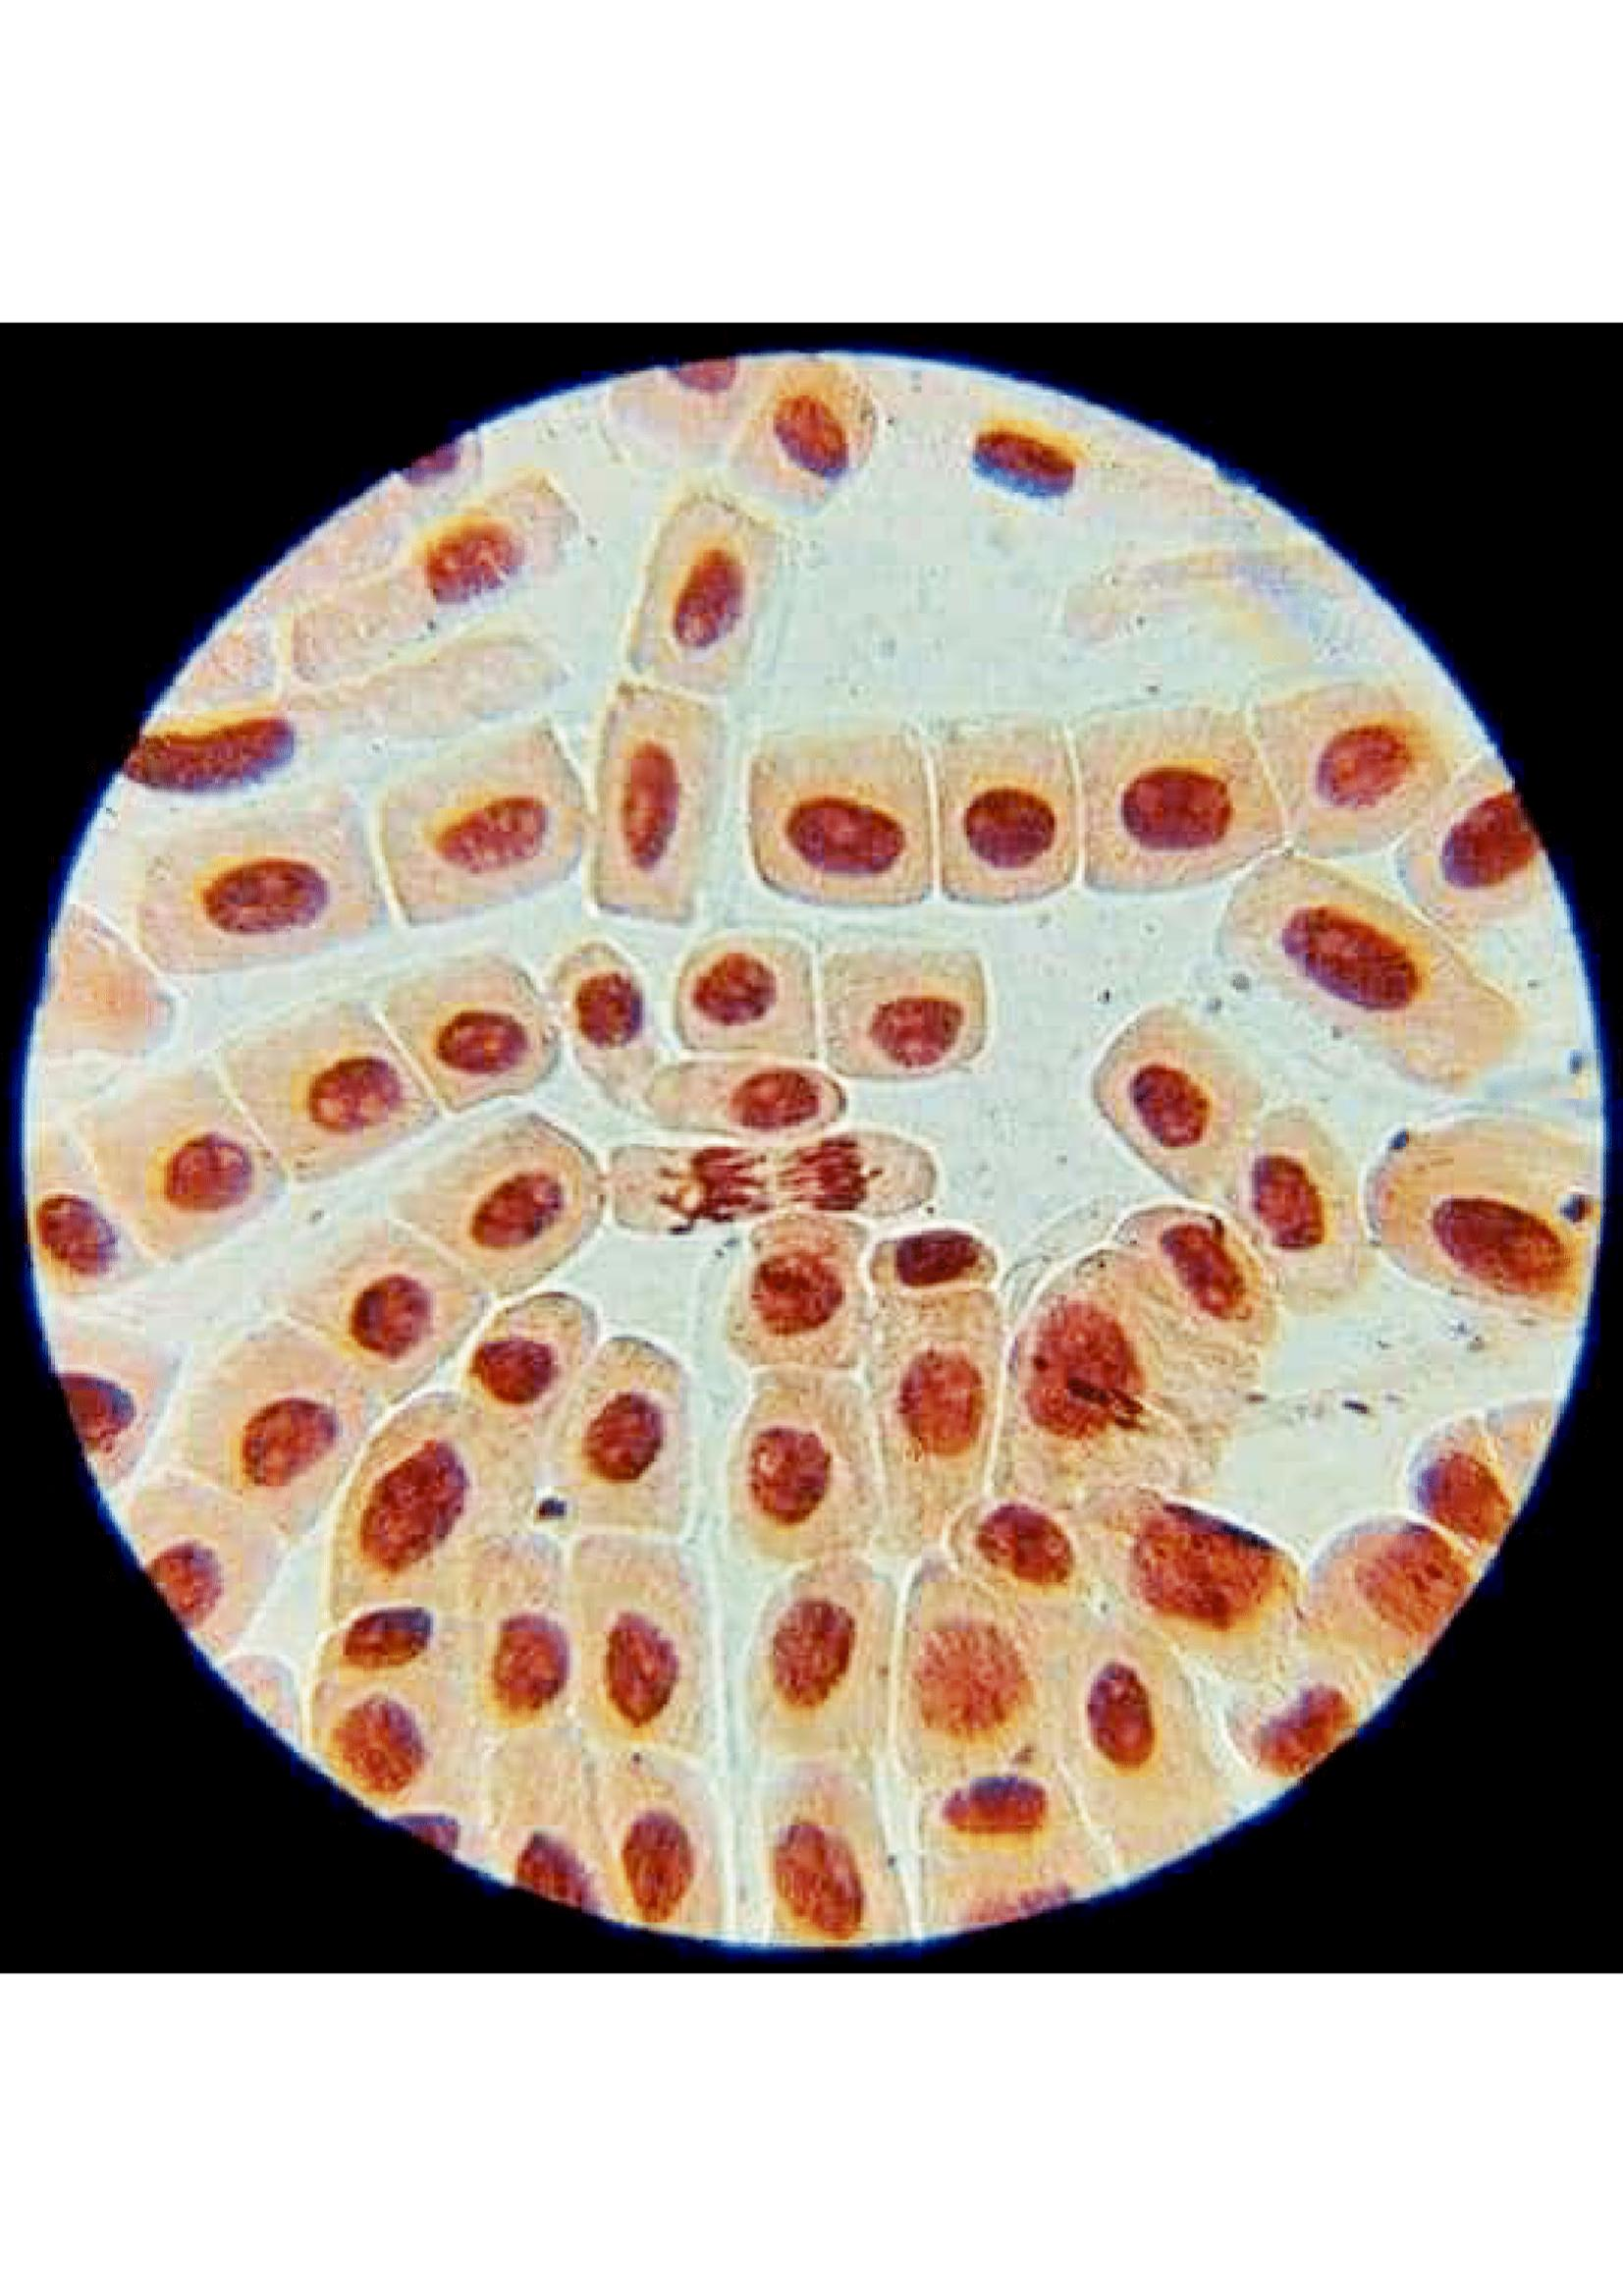

In [21]:
from ultralytics import YOLO
from PIL import Image as PILImage
from IPython.display import display

detector = YOLO("runs/detect/mitosis_yolo11n_20260608/weights/best.pt")

results = detector.predict(
    source="Onion-Cell-Merged-v5-2/test/images/A_5_png.rf.4a541ca57c217074a8ee48ee72463f62.jpg",
    conf=0.25,
    imgsz=320,
    device="mps",
    save=True
)

display(PILImage.fromarray(results[0].plot()[..., ::-1]))